In [2]:
from models.ns_data import open_memmap, build_val_pairs_for, make_ns_val_loader
from models.scent import SCENTNavierStokesModel, path_for
from models.eval import evaluate_loader, pretty_print_metrics, eval_grid_scent

# --- data ---
BASE_DIR = "/pscratch/sd/d/dpark1/NSData"
NAME = "100k"
MEAN, STD = 0.0, 2.4036
DATASET_TAG = "full"   # or "10pct"
SPARSITY_PCT = 20       # 2, 5, 20
SPARSITY = SPARSITY_PCT / 100.0

mem = open_memmap(BASE_DIR, NAME)
val_pairs, T = build_val_pairs_for(mem, DATASET_TAG)
val_loader, meta = make_ns_val_loader(mem, val_pairs, sparsity=SPARSITY, mean=MEAN, std=STD, batch_size=32)

# --- SCENT single ckpt ---
root = "NavierStokesCheckpoints/SCENT"
ckpt = path_for(root, dataset_tag=DATASET_TAG, sparsity_pct=SPARSITY_PCT)
scent = SCENTNavierStokesModel(ckpt, device="cuda:0")
metrics = evaluate_loader(scent, val_loader, crps_k=10, std=STD)
pretty_print_metrics(metrics, prefix=f"[SCENT {DATASET_TAG}/{SPARSITY_PCT}%] ")

# --- all 6 ckpts (full/10pct × 2/5/20) ---
rows = eval_grid_scent(root, dataset_tags=("full","10pct"), sparsity_pcts=(2,5,20),
                       loader=val_loader, crps_k=10, std=STD)
for r in rows:
    pretty_print_metrics(r, prefix=f"[SCENT {r['dataset_tag']}/{r['sparsity_pct']}%] ")


[NS Sparse] pairs=4900, T=50, HW=(64,64), sparsity=0.2, normalize=True, unit_range=False, fixed_mask_per_sample=True
[SCENT full/20%] MSE=0.0552 | RMSE=0.2350 | MAE=0.1620 | CRPS=0.1620 | RMSE_u=0.5649 | MAE_u=0.3893 | CRPS_u=0.3893
[SCENT full/2%] MSE=0.2960 | RMSE=0.5441 | MAE=0.4004 | CRPS=0.4004 | RMSE_u=1.3078 | MAE_u=0.9623 | CRPS_u=0.9623
[SCENT full/5%] MSE=0.1217 | RMSE=0.3488 | MAE=0.2481 | CRPS=0.2481 | RMSE_u=0.8384 | MAE_u=0.5963 | CRPS_u=0.5963
[SCENT full/20%] MSE=0.0552 | RMSE=0.2350 | MAE=0.1620 | CRPS=0.1620 | RMSE_u=0.5649 | MAE_u=0.3893 | CRPS_u=0.3893
[SCENT 10pct/2%] MSE=0.6611 | RMSE=0.8131 | MAE=0.6103 | CRPS=0.6103 | RMSE_u=1.9544 | MAE_u=1.4669 | CRPS_u=1.4669
[SCENT 10pct/5%] MSE=0.3927 | RMSE=0.6267 | MAE=0.4617 | CRPS=0.4617 | RMSE_u=1.5062 | MAE_u=1.1097 | CRPS_u=1.1097
[SCENT 10pct/20%] MSE=0.3787 | RMSE=0.6154 | MAE=0.4488 | CRPS=0.4488 | RMSE_u=1.4791 | MAE_u=1.0787 | CRPS_u=1.0787


In [1]:
from models.ns_data import open_memmap
from models.eval import eval_grid_scent_autoload, pretty_print_metrics

BASE_DIR = "/pscratch/sd/d/dpark1/NSData"
NAME = "100k"
MEAN, STD = 0.0, 2.4036

mem = open_memmap(BASE_DIR, NAME)

rows = eval_grid_scent_autoload(
    root="NavierStokesCheckpoints/SCENT",
    mem=mem,
    dataset_tags=("full","10pct"),
    sparsity_pcts=(2,5,20),
    mean=MEAN,
    std=STD,
    batch_size=32,
    mask_seed=0,
    crps_k=10,
)

for r in rows:
    pretty_print_metrics(r, prefix=f"[SCENT {r['dataset_tag']}/{r['sparsity_pct']}%] ")


/pscratch/sd/k/kevinval/Diffusion-Probabilistic-Models/models/scent.py:268: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=self.devi

[SCENT full/2%] MSE=0.7544 | RMSE=0.8686 | MAE=0.6240 | CRPS=0.6240 | RMSE_u=2.0877 | MAE_u=1.4998 | CRPS_u=1.4998
[SCENT full/5%] MSE=0.2781 | RMSE=0.5274 | MAE=0.3650 | CRPS=0.3650 | RMSE_u=1.2677 | MAE_u=0.8772 | CRPS_u=0.8772
[SCENT full/20%] MSE=0.0552 | RMSE=0.2350 | MAE=0.1620 | CRPS=0.1620 | RMSE_u=0.5649 | MAE_u=0.3893 | CRPS_u=0.3893
[SCENT 10pct/2%] MSE=1.0764 | RMSE=1.0375 | MAE=0.7680 | CRPS=0.7680 | RMSE_u=2.4937 | MAE_u=1.8460 | CRPS_u=1.8460
[SCENT 10pct/5%] MSE=0.5924 | RMSE=0.7697 | MAE=0.5557 | CRPS=0.5557 | RMSE_u=1.8500 | MAE_u=1.3357 | CRPS_u=1.3357
[SCENT 10pct/20%] MSE=0.3787 | RMSE=0.6154 | MAE=0.4488 | CRPS=0.4488 | RMSE_u=1.4791 | MAE_u=1.0787 | CRPS_u=1.0787


In [1]:
# --- shared imports & config ---
from models.ns_data import open_memmap
from models.eval import (
    eval_grid_scent_autoload,
    eval_grid_omnifield_autoload,
    pretty_print_metrics,
)

BASE_DIR = "/pscratch/sd/d/dpark1/NSData"
NAME = "100k"
MEAN, STD = 0.0, 2.4036

DATASET_TAGS = ("full", "10pct")
SPARSITY_PCTS = (2, 5, 20)
BATCH_SIZE = 32
MASK_SEED = 0
CRPS_K = 10

# --- open memmap once ---
mem = open_memmap(BASE_DIR, NAME)

# --- SCENT ---
scent_rows = eval_grid_scent_autoload(
    root="NavierStokesCheckpoints/SCENT",
    mem=mem,
    dataset_tags=DATASET_TAGS,
    sparsity_pcts=SPARSITY_PCTS,
    mean=MEAN,
    std=STD,
    batch_size=BATCH_SIZE,
    mask_seed=MASK_SEED,
    crps_k=CRPS_K,
)
for r in scent_rows:
    pretty_print_metrics(r, prefix=f"[SCENT {r['dataset_tag']}/{r['sparsity_pct']}%] ")

# --- OmniField ---
omni_rows = eval_grid_omnifield_autoload(
    root="NavierStokesCheckpoints/OMNIFIELD",
    mem=mem,
    dataset_tags=DATASET_TAGS,
    sparsity_pcts=SPARSITY_PCTS,
    mean=MEAN,
    std=STD,
    batch_size=BATCH_SIZE,
    mask_seed=MASK_SEED,
    crps_k=CRPS_K,
)
for r in omni_rows:
    pretty_print_metrics(r, prefix=f"[OMNI  {r['dataset_tag']}/{r['sparsity_pct']}%] ")

# --- optional: keep a combined table in memory for later ---
all_rows = [{"model": "SCENT", **r} for r in scent_rows] + [{"model": "OMNI", **r} for r in omni_rows]


/pscratch/sd/k/kevinval/Diffusion-Probabilistic-Models/models/scent.py:268: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=self.devi

[SCENT full/2%] MSE=0.7544 | RMSE=0.8686 | MAE=0.6240 | CRPS=0.6240 | RMSE_u=2.0877 | MAE_u=1.4998 | CRPS_u=1.4998
[SCENT full/5%] MSE=0.2781 | RMSE=0.5274 | MAE=0.3650 | CRPS=0.3650 | RMSE_u=1.2677 | MAE_u=0.8772 | CRPS_u=0.8772
[SCENT full/20%] MSE=0.0552 | RMSE=0.2350 | MAE=0.1620 | CRPS=0.1620 | RMSE_u=0.5649 | MAE_u=0.3893 | CRPS_u=0.3893
[SCENT 10pct/2%] MSE=1.0764 | RMSE=1.0375 | MAE=0.7680 | CRPS=0.7680 | RMSE_u=2.4937 | MAE_u=1.8460 | CRPS_u=1.8460
[SCENT 10pct/5%] MSE=0.5924 | RMSE=0.7697 | MAE=0.5557 | CRPS=0.5557 | RMSE_u=1.8500 | MAE_u=1.3357 | CRPS_u=1.3357
[SCENT 10pct/20%] MSE=0.3787 | RMSE=0.6154 | MAE=0.4488 | CRPS=0.4488 | RMSE_u=1.4791 | MAE_u=1.0787 | CRPS_u=1.0787


/pscratch/sd/k/kevinval/Diffusion-Probabilistic-Models/models/omnifield.py:261: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=self.

[OMNI  full/2%] MSE=0.8450 | RMSE=0.9193 | MAE=0.6694 | CRPS=0.6694 | RMSE_u=2.2095 | MAE_u=1.6091 | CRPS_u=1.6091
[OMNI  full/5%] MSE=0.3625 | RMSE=0.6021 | MAE=0.4233 | CRPS=0.4233 | RMSE_u=1.4472 | MAE_u=1.0174 | CRPS_u=1.0174
[OMNI  full/20%] MSE=0.0554 | RMSE=0.2354 | MAE=0.1586 | CRPS=0.1586 | RMSE_u=0.5658 | MAE_u=0.3812 | CRPS_u=0.3812
[OMNI  10pct/2%] MSE=1.1927 | RMSE=1.0921 | MAE=0.8230 | CRPS=0.8230 | RMSE_u=2.6250 | MAE_u=1.9781 | CRPS_u=1.9781
[OMNI  10pct/5%] MSE=0.7714 | RMSE=0.8783 | MAE=0.6538 | CRPS=0.6538 | RMSE_u=2.1111 | MAE_u=1.5714 | CRPS_u=1.5714
[OMNI  10pct/20%] MSE=0.3260 | RMSE=0.5710 | MAE=0.4122 | CRPS=0.4122 | RMSE_u=1.3723 | MAE_u=0.9908 | CRPS_u=0.9908


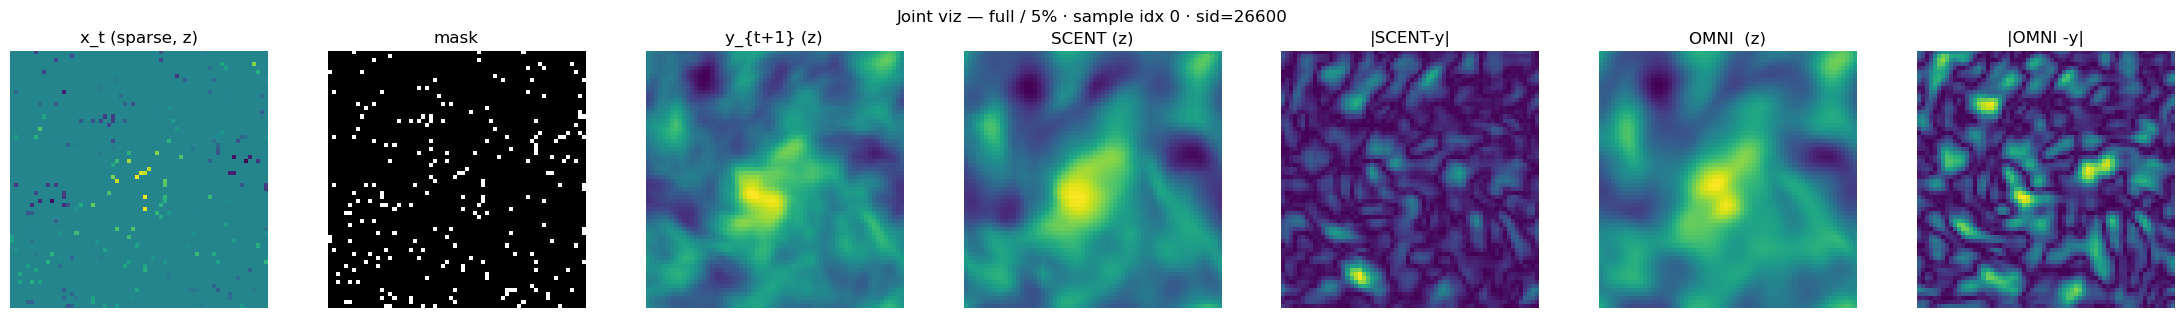

In [4]:
# Joint single-sample viz: SCENT + OmniField (device-safe metrics)
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from einops import rearrange

from models.ns_data import (
    open_memmap, build_val_pairs_for, make_ns_val_loader, make_subset_loader
)
from models.scent import SCENTNavierStokesModel, path_for as scent_path_for
from models.omnifield import OmniFieldNavierStokesModel, path_for as omni_path_for

# ---- config ----
BASE_DIR = "/pscratch/sd/d/dpark1/NSData"
NAME = "100k"
MEAN, STD = 0.0, 2.4036

DATASET_TAG  = "full"    # or "10pct"
SPARSITY_PCT = 5         # 2, 5, or 20
SAMPLE_IDX   = 0         # which row to visualize
DEVICE       = "cuda:0" if torch.cuda.is_available() else "cpu"

SHOW_ERROR_MAPS = True   # show |pred - y|
UNNORM_VIZ     = False   # visualize in original units too

# ---- data: build correct val loader for THIS sparsity, then take one row ----
mem = open_memmap(BASE_DIR, NAME)
val_pairs, _ = build_val_pairs_for(mem, DATASET_TAG)
val_loader, meta = make_ns_val_loader(
    mem=mem,
    val_pairs=val_pairs,
    sparsity=SPARSITY_PCT / 100.0,
    mean=MEAN,
    std=STD,
    batch_size=1,
    mask_seed=0,
    verbose=False,
)
one_loader = make_subset_loader(meta.dataset, [SAMPLE_IDX], batch_size=1)
x_sparse, y, mask, sid = next(iter(one_loader))   # [1,1,H,W], [1,1,H,W], [1,H,W], [1]

# ---- load models for matching dataset/sparsity ----
scent_ckpt = scent_path_for("NavierStokesCheckpoints/SCENT", dataset_tag=DATASET_TAG,   sparsity_pct=SPARSITY_PCT)
omni_ckpt  = omni_path_for ("NavierStokesCheckpoints/OMNIFIELD", dataset_tag=DATASET_TAG, sparsity_pct=SPARSITY_PCT)

scent = SCENTNavierStokesModel(scent_ckpt, device=DEVICE)
omni  = OmniFieldNavierStokesModel(omni_ckpt,  device=DEVICE)

# ---- predict on just this one sample ----
with torch.no_grad():
    pred_scent = scent.predict(x_sparse, mask)   # [1,1,H,W]
    pred_omni  = omni.predict(x_sparse,  mask)   # [1,1,H,W]

# ---- single-sample metrics (normalized space), with device alignment ----
def nm(pred, target):
    if pred.device != target.device:
        target = target.to(pred.device)
    return {
        "MSE": F.mse_loss(pred, target, reduction="mean").item(),
        "MAE": F.l1_loss (pred, target, reduction="mean").item(),
    }

metrics_scent = nm(pred_scent, y)
metrics_omni  = nm(pred_omni,  y)

# ---- plotting helper ----
def show_joint(x_sparse, y, mask, preds: dict, *,
               title_prefix="", unnorm=False, mean=0.0, std=1.0, show_errors=True):
    xs = x_sparse[0, 0].cpu().numpy()
    yt = y[0, 0].cpu().numpy()
    ms = mask[0].cpu().numpy()

    panels = [("x_t (sparse, z)", xs), ("mask", ms), ("y_{t+1} (z)", yt)]
    for name, t in preds.items():
        img = t[0, 0].detach().cpu().numpy()
        panels.append((f"{name} (z)", img))
        if show_errors:
            panels.append((f"|{name}-y|", abs(img - yt)))

    if unnorm:
        yt_u = yt * std + mean
        panels.append(("y_{t+1} (unnorm)", yt_u))
        for name, t in preds.items():
            img_u = (t[0, 0].detach().cpu().numpy() * std + mean)
            panels.append((f"{name} (unnorm)", img_u))
            if show_errors:
                panels.append((f"|{name}-y| (unnorm)", abs(img_u - yt_u)))

    n = len(panels)
    plt.figure(figsize=(3.2 * n, 3.2))
    for i, (ttl, img) in enumerate(panels, 1):
        plt.subplot(1, n, i)
        if ttl.lower().startswith("mask"):
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img, cmap="viridis")
        plt.title(ttl); plt.axis("off")
    plt.suptitle(f"{title_prefix} {DATASET_TAG} / {SPARSITY_PCT}% · sample idx {SAMPLE_IDX} · sid={int(sid)}")
    plt.tight_layout(); plt.show()

# ---- visualize ----
preds = {
    f"SCENT": pred_scent,
    f"OMNI ":  pred_omni,
}
show_joint(
    x_sparse, y, mask, preds,
    title_prefix="Joint viz —",
    unnorm=UNNORM_VIZ, mean=MEAN, std=STD,
    show_errors=SHOW_ERROR_MAPS,
)
